# Data Reduction Using t-sne demonstration in Python

## Background

- Data on national athletics records for various countries is available.

- Data Source: Applied Multivariate Statistical Analysis by Richard A. Johnson , Dean W. Wichern

- Sample size is 55 countries' athletics  records for 8  different athletics events – 100 meters to Marathon

Since each country is described by multiple performance variables, the data is inherently high-dimensional. In such scenarios, direct visualization and traditional distance-based methods often fail to reveal meaningful patterns due to data sparsity. To overcome this, t-Distributed Stochastic Neighbor Embedding (t-SNE) is used as a non-linear dimensionality reduction technique. t-SNE effectively preserves local similarities, enabling visualization of complex structures and natural groupings among countries based on athletics performance.

## Objectives

The objectives of this notebook are:

- Understand the need for non-linear dimensionality reduction in high-dimensional data

- Learn the intuition and working principles of t-Distributed Stochastic Neighbor Embedding (t-SNE)

- Visualize high-dimensional data in 2D/3D using t-SNE embeddings



## Data Description

| Column Name     | Description                                      |
|-----------------|--------------------------------------------------|
| 100m_s          | Time taken to complete 100 meters (seconds)     |
| 200m_s          | Time taken to complete 200 meters (seconds)     |
| 400m_s          | Time taken to complete 400 meters (seconds)     |
| 800m_min        | Time taken to complete 800 meters (minutes)     |
| 1500m_min       | Time taken to complete 1500 meters (minutes)    |
| 5000m_min       | Time taken to complete 5000 meters (minutes)    |
| 10000m_min      | Time taken to complete 10000 meters (minutes)   |
| Marathon_min   | Time taken to complete a marathon (minutes)     |


### Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

### Import Data

In [2]:
athletics_df = pd.read_csv('Athleticsdata.csv')
#Drop categorical column
athletics = athletics_df.drop(columns=['Country'])
athletics_df.head()

,Country,100m_s,200m_s,400m_s,800m_min,1500m_min,5000m_min,10000m_min,Marathon_min
0,Argentina,10.39,20.81,46.84,1.81,3.70,14.04,29.36,137.72
1,Australia,10.31,20.06,44.84,1.74,3.57,13.28,27.66,128.30
2,Austria,10.44,20.81,46.82,1.79,3.60,13.26,27.72,135.90
3,Belgium,10.34,20.68,45.04,1.73,3.60,13.22,27.45,129.95
4,Bermuda,10.28,20.58,45.91,1.80,3.75,14.68,30.55,146.62


### Standardize the data

In [3]:
scaler = StandardScaler()
athletics_scaled = scaler.fit_transform(athletics)

### Apply t-SNE

We project the 8-dimensional athletics performance data into 2D for visualization

- n_components: Number of dimensions in the low-dimensional embedding (usually 2 or 3 for visualization).

- perplexity: Controls the balance between local and global structure by defining the effective number of nearest neighbors.

- learning_rate: Determines the step size used during optimization of the t-SNE embedding.

- random_state: Fixes the random seed to ensure reproducible t-SNE results.

In [4]:

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

athletics_tsne = tsne.fit_transform(athletics_scaled)


### Create a DataFrame for visualization

In [5]:
import pandas as pd

tsne_df = pd.DataFrame(
    athletics_tsne,
    columns=['TSNE_1', 'TSNE_2']
)
tsne_df["Country"] = athletics_df["Country"].values

tsne_df.head()


,TSNE_1,TSNE_2,Country
0,-8.141805,-35.510818,Argentina
1,-6.421889,40.839615,Australia
2,-2.569855,-7.809846,Austria
3,-7.360434,28.405796,Belgium
4,-20.882544,-44.536392,Bermuda


### Visualize t-SNE embedding

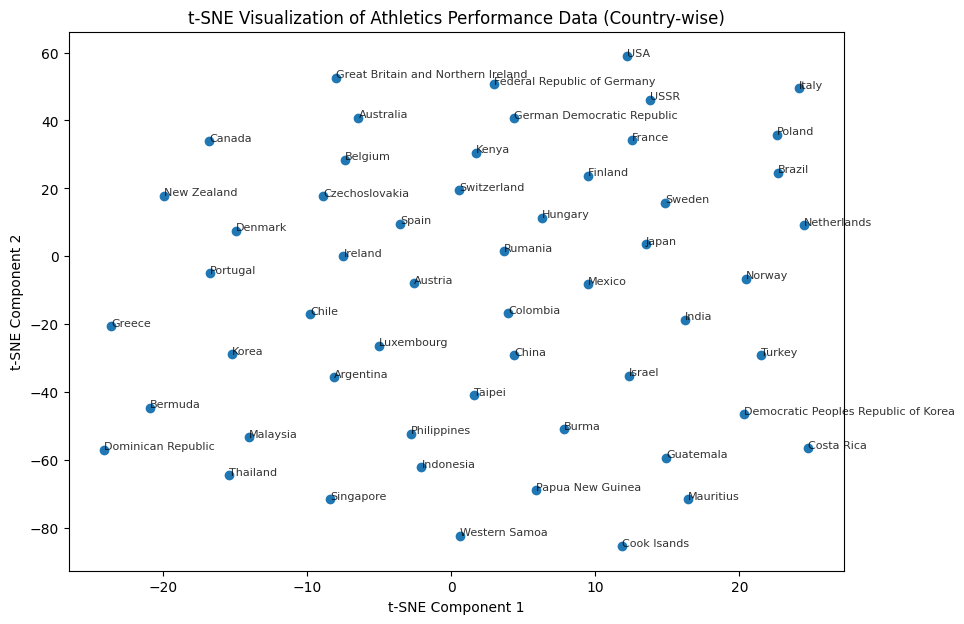

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(tsne_df['TSNE_1'], tsne_df['TSNE_2'])

for i in range(len(tsne_df)):
    plt.text(
        tsne_df.loc[i, 'TSNE_1'],
        tsne_df.loc[i, 'TSNE_2'],
        tsne_df.loc[i, 'Country'],
        fontsize=8,
        alpha=0.8
    )

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Athletics Performance Data (Country-wise)')
plt.show()


### Inference :
This plot helps to identify similar performing countries in athletics event.